In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/cars24-car-price.csv")

In [ ]:
df

,full_name,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti Alto Std,1.20,2012.0,Individual,120000,Petrol,Manual,19.70,796.0,46.30,5.0
1,Hyundai Grand i10 Asta,5.50,2016.0,Individual,20000,Petrol,Manual,18.90,1197.0,82.00,5.0
2,Hyundai i20 Asta,2.15,2010.0,Individual,60000,Petrol,Manual,17.00,1197.0,80.00,5.0
3,Maruti Alto K10 2010-2014 VXI,2.26,2012.0,Individual,37000,Petrol,Manual,20.92,998.0,67.10,5.0
4,Ford Ecosport 2015-2021 1.5 TDCi Titanium BSIV,5.70,2015.0,Dealer,30000,Diesel,Manual,22.77,1498.0,98.59,5.0
...,...,...,...,...,...,...,...,...,...,...,...
19975,Toyota Platinum Etios 1.4 GXD,6.50,2017.0,Dealer,69480,Diesel,Manual,23.59,1364.0,67.05,5.0
19976,Maruti Ertiga BSIV VXI,9.25,2019.0,Dealer,18000,Petrol,Manual,17.50,1373.0,91.10,7.0
19977,Skoda Rapid 1.5 TDI Elegance,4.25,2015.0,Dealer,67000,Diesel,Manual,21.14,1498.0,103.52,5.0
19978,Mahindra XUV500 W6 2WD,12.25,2016.0,Dealer,3800000,Diesel,Manual,16.00,2179.0,140.00,7.0


In [ ]:
df['seller_type'].value_counts()

,count
seller_type,
Dealer,11973
Individual,7817
Trustmark Dealer,190


In [ ]:
df['fuel_type'].value_counts()

,count
fuel_type,
Diesel,9817
Petrol,9767
CNG,316
LPG,66
Electric,14


In [ ]:
df['transmission_type'].value_counts()

,count
transmission_type,
Manual,16029
Automatic,3951


In [ ]:
df.shape

(19980, 11)

Problem Statement: Predicting the selling price or resale value of used cars based on their features.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19980 entries, 0 to 19979
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_name          19980 non-null  object 
 1   selling_price      19980 non-null  float64
 2   year               19980 non-null  float64
 3   seller_type        19980 non-null  object 
 4   km_driven          19980 non-null  int64  
 5   fuel_type          19980 non-null  object 
 6   transmission_type  19980 non-null  object 
 7   mileage            19980 non-null  float64
 8   engine             19980 non-null  float64
 9   max_power          19980 non-null  float64
 10  seats              19980 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,selling_price,year,km_driven,mileage,engine,max_power,seats
count,19980.000000,19980.000000,1.998000e+04,19980.000000,19980.000000,19980.000000,19980.000000
mean,7.392066,2014.525125,5.824488e+04,19.347219,1476.327401,97.854443,5.317868
std,9.103088,3.249185,5.172509e+04,4.620053,520.449398,45.080670,0.835370
min,0.250000,1991.000000,1.000000e+02,0.000000,0.000000,5.000000,2.000000
25%,3.400000,2013.000000,3.116425e+04,16.800000,1197.000000,73.900000,5.000000
50%,5.200000,2015.000000,5.200000e+04,19.160000,1248.000000,86.700000,5.000000
75%,7.850000,2017.000000,7.400000e+04,22.320000,1582.000000,112.000000,5.000000
max,395.000000,2021.000000,3.800000e+06,120.000000,6752.000000,626.000000,14.000000


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

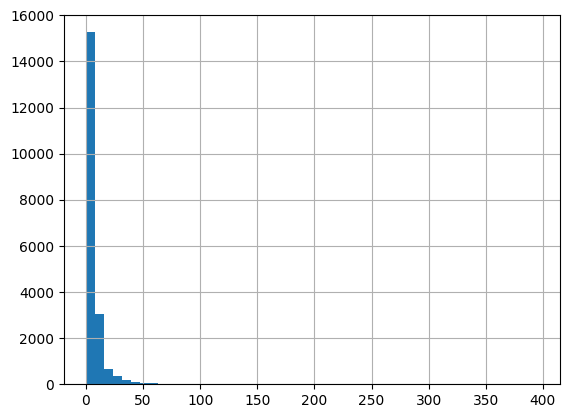

In [ ]:
df['selling_price'].hist(bins=50)

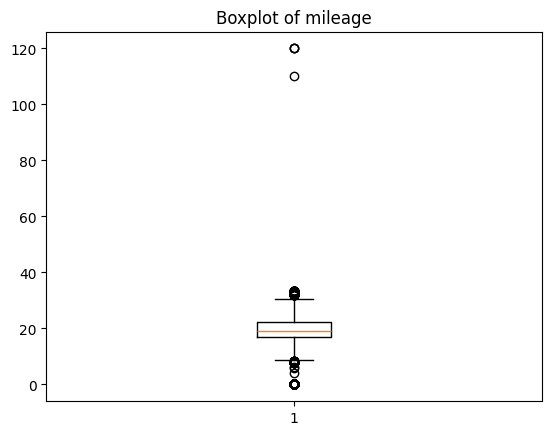

In [ ]:


plt.boxplot(df['mileage'])
plt.title('Boxplot of mileage')
plt.show()

In [ ]:
df[df["mileage"] == 0.0].shape

(159, 11)

In [ ]:
df[df["mileage"] > 40].mileage.describe()

,mileage
count,4.0
mean,117.5
std,5.0
min,110.0
25%,117.5
50%,120.0
75%,120.0
max,120.0


In [ ]:
df[df["mileage"] > 40]

,full_name,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats
11966,Mahindra e2oPlus P6,4.00,2018.0,Dealer,26000,Electric,Automatic,110.0,1476.327401,25.4,4.0
15684,Mahindra e2o T2,3.60,2015.0,Dealer,42862,Electric,Automatic,120.0,0.000000,25.5,5.0
17782,Mahindra e2o T2,4.50,2015.0,Dealer,40000,Electric,Automatic,120.0,0.000000,25.5,5.0
18401,Mahindra e2o Premium,3.25,2013.0,Individual,50000,Electric,Automatic,120.0,0.000000,25.5,5.0


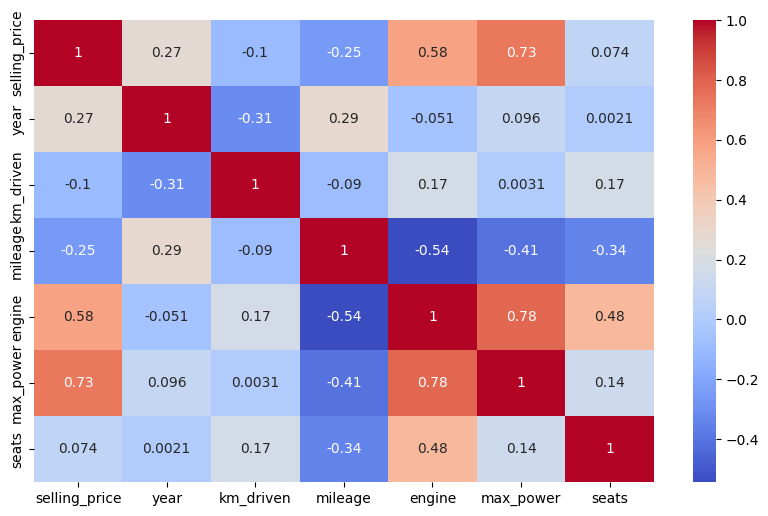

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

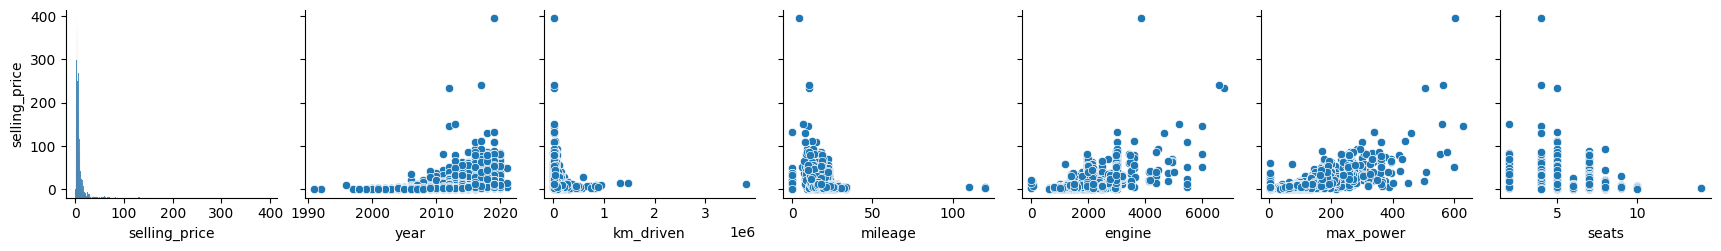

In [ ]:
sns.pairplot(df, y_vars=["selling_price"]);

In [ ]:
df["make"] = df.full_name.apply(lambda x : x.split()[0])
df["model"] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))
df = df.drop("full_name", axis=1)


/tmp/ipykernel_730/2297619072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["make"] = df.full_name.apply(lambda x : x.split()[0])
/tmp/ipykernel_730/2297619072.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["model"] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))


In [ ]:
display(df.head())

,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats,make,model
0,1.20,2012.0,Individual,120000,Petrol,Manual,19.70,796.0,46.30,5.0,Maruti,Alto Std
1,5.50,2016.0,Individual,20000,Petrol,Manual,18.90,1197.0,82.00,5.0,Hyundai,Grand i10 Asta
2,2.15,2010.0,Individual,60000,Petrol,Manual,17.00,1197.0,80.00,5.0,Hyundai,i20 Asta
3,2.26,2012.0,Individual,37000,Petrol,Manual,20.92,998.0,67.10,5.0,Maruti,Alto K10 2010-2014 VXI
4,5.70,2015.0,Dealer,30000,Diesel,Manual,22.77,1498.0,98.59,5.0,Ford,Ecosport 2015-2021 1.5 TDCi Titanium BSIV


In [ ]:
encoded_make = df.groupby('make')['selling_price'].transform('mean')

In [ ]:
display(df.describe(include="object"))

,seller_type,fuel_type,transmission_type,make,model
count,19842,19842,19842,19842,19842
unique,3,5,2,42,3321
top,Dealer,Diesel,Manual,Maruti,Swift Dzire VDI
freq,11898,9751,15929,5608,206


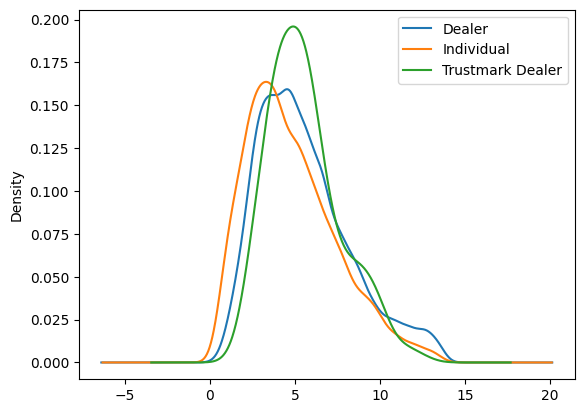

In [ ]:
df.loc[df.selling_price<=df.selling_price.quantile(0.9)].groupby('seller_type')['selling_price'].plot.density();
plt.legend();

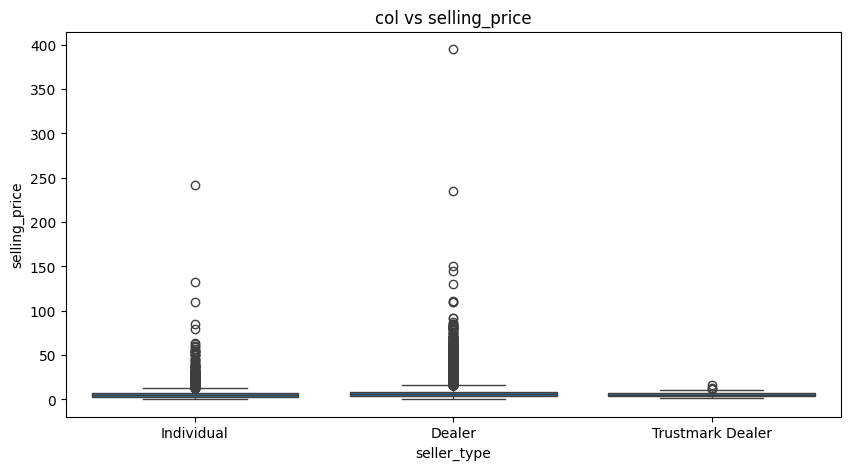

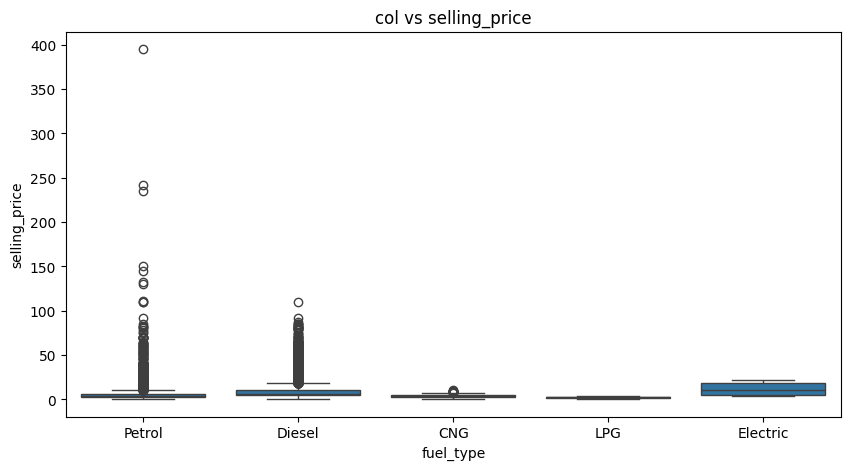

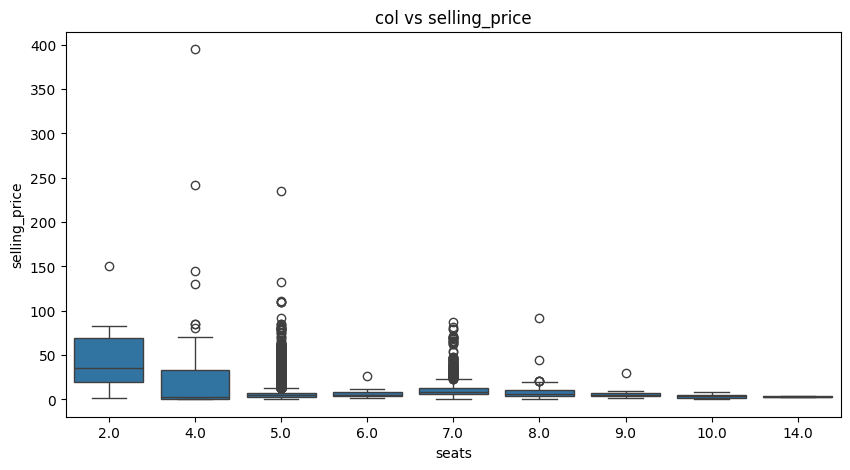

In [ ]:
for col in ['seller_type', 'fuel_type', 'seats']:
    plt.figure(figsize=(10,5))
    sns.boxplot(y='selling_price',x=col, data=df)
    plt.title('col vs selling_price')
    plt.show()

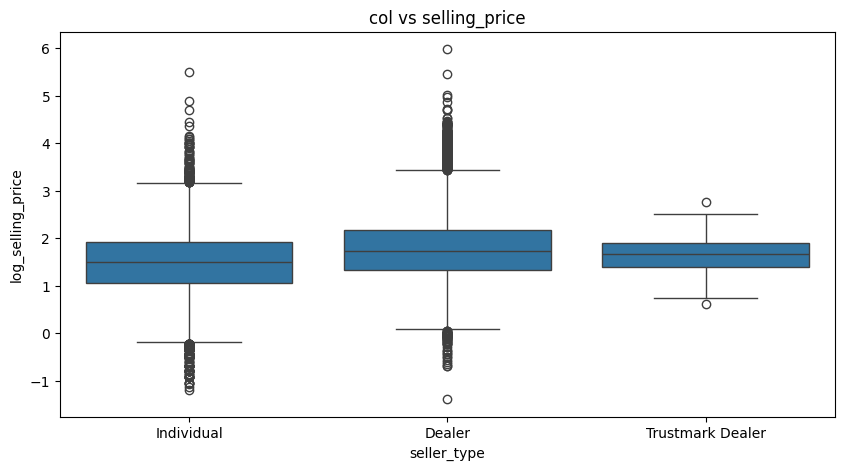

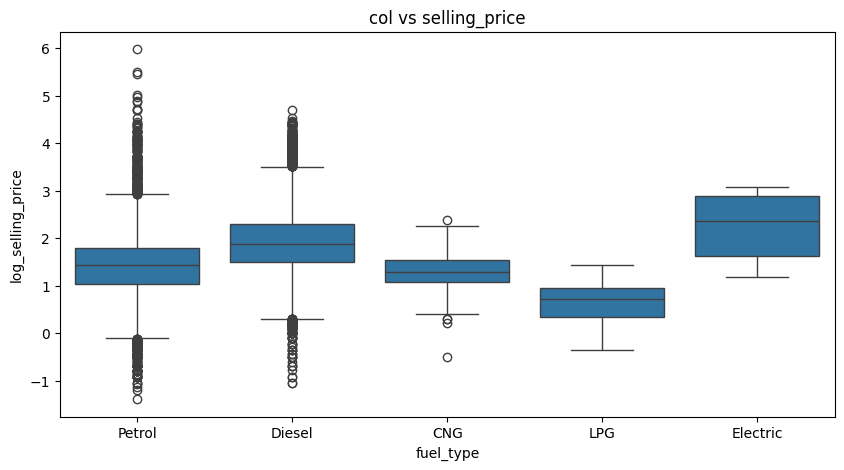

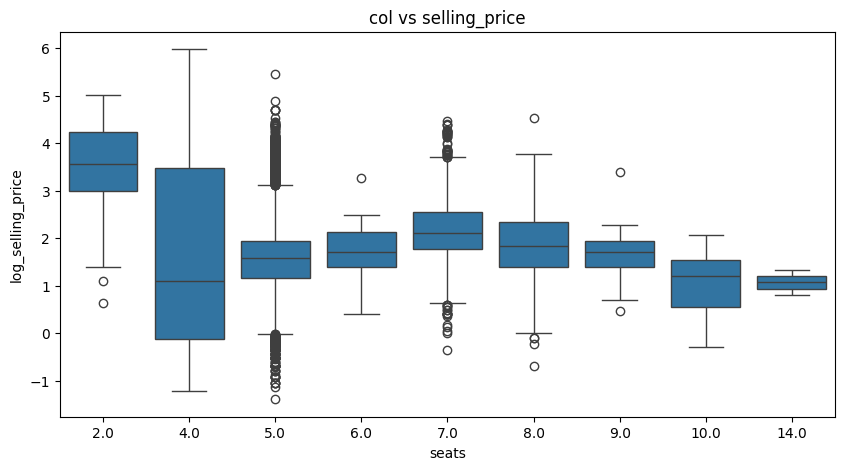

In [ ]:
df["log_selling_price"] = np.log(df["selling_price"].values)

for col in ['seller_type', 'fuel_type', 'seats']:
    plt.figure(figsize=(10,5))
    sns.boxplot(y='log_selling_price',x=col, data=df)
    plt.title('col vs selling_price')
    plt.show()

In [ ]:
len(df["make"].unique())

42

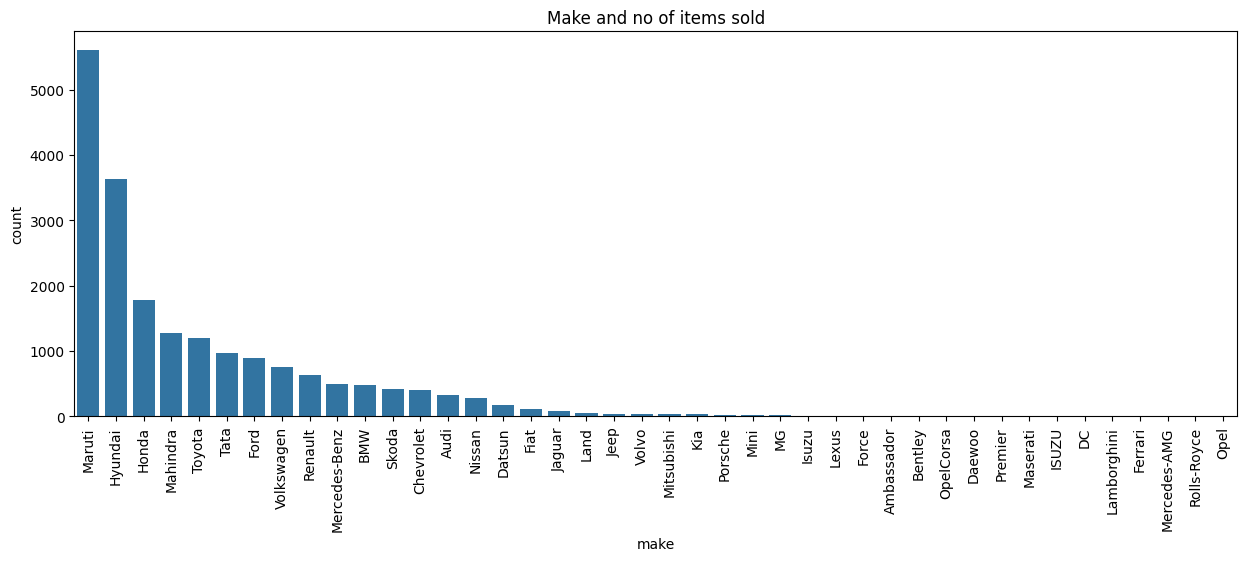

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='make', data=df, order = df['make'].value_counts().index)
plt.xticks(rotation=90);
plt.title("Make and no of items sold")
plt.show()

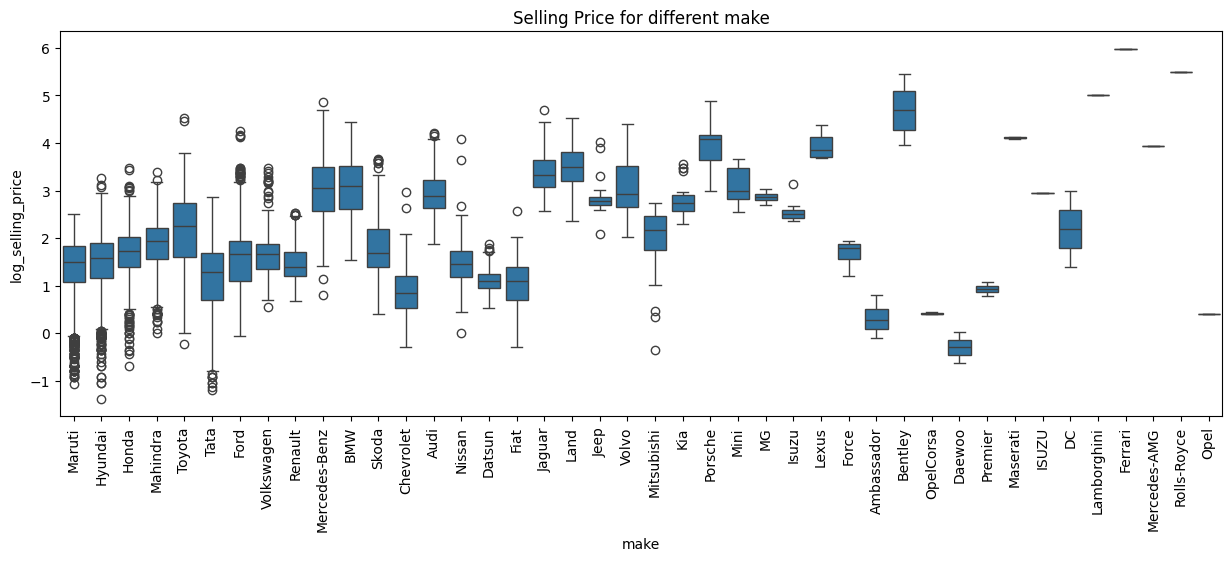

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(y='log_selling_price',x='make', data=df, order = df['make'].value_counts().index)
plt.xticks(rotation=90);
plt.title("Selling Price for different make")
plt.show()

In [ ]:

df.drop("log_selling_price", axis=1, inplace=True)

In [ ]:
df.head()

,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats,make,model
0,1.20,2012.0,Individual,120000,Petrol,Manual,19.70,796.0,46.30,5.0,Maruti,Alto Std
1,5.50,2016.0,Individual,20000,Petrol,Manual,18.90,1197.0,82.00,5.0,Hyundai,Grand i10 Asta
2,2.15,2010.0,Individual,60000,Petrol,Manual,17.00,1197.0,80.00,5.0,Hyundai,i20 Asta
3,2.26,2012.0,Individual,37000,Petrol,Manual,20.92,998.0,67.10,5.0,Maruti,Alto K10 2010-2014 VXI
4,5.70,2015.0,Dealer,30000,Diesel,Manual,22.77,1498.0,98.59,5.0,Ford,Ecosport 2015-2021 1.5 TDCi Titanium BSIV


In [ ]:
from datetime import datetime

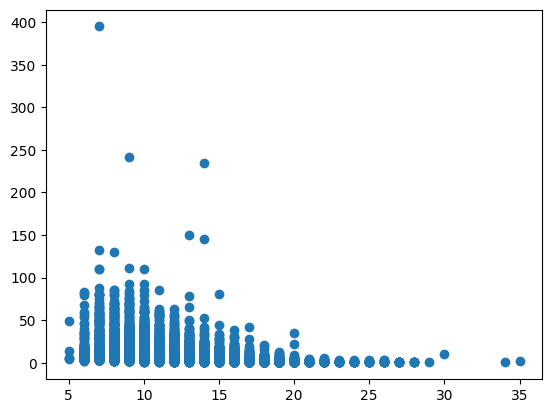

In [ ]:
current_year = datetime.now().year
age = current_year - df['year']
plt.scatter(age, df.selling_price)

In [ ]:
transmission_dummy = pd.get_dummies(df["transmission_type"])
df = pd.concat([df, transmission_dummy], axis=1)
df = df.drop(["transmission_type", "Automatic"], axis=1)
df = df.rename(columns={"Manual": "transmission_type"})
df.sample(frac=1).head(2)

,selling_price,year,seller_type,km_driven,fuel_type,mileage,engine,max_power,seats,make,model,transmission_type
13277,5.9,2018.0,Dealer,21000,Petrol,21.40,1197.0,83.1,5.0,Maruti,Baleno Delta 1.2,True
15095,27.9,2015.0,Dealer,58000,Diesel,15.26,2143.0,203.2,5.0,Mercedes-Benz,M-Class ML 250 CDI,False


In [ ]:
fuel_type_dummy = pd.get_dummies(df["fuel_type"], prefix="fuel", dtype=int)
df = pd.concat([df, fuel_type_dummy], axis=1)
df = df.drop(["fuel_type", "fuel_CNG"], axis=1)
display(df.sample(frac=1).head(2))

,selling_price,year,seller_type,km_driven,mileage,engine,max_power,seats,make,model,transmission_type,False,True,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
15923,3.5,2012.0,Individual,200000,17.60,1496.0,88.73,5.0,Toyota,Etios G,True,0,1,0,0,0,1
13904,6.5,2014.0,Individual,40000,16.02,1373.0,93.70,7.0,Maruti,Ertiga VXI,True,0,1,0,0,0,1


In [ ]:
fuel_type_dummy = pd.get_dummies(df["fuel_type"], prefix="seats")
fuel_type_dummy.sample(frac=1).head(2)

,seats_CNG,seats_Diesel,seats_Electric,seats_LPG,seats_Petrol
5834,False,True,False,False,False
6020,False,True,False,False,False


In [ ]:
fuel_type_dummy = fuel_type_dummy[fuel_type_dummy.columns[1:]]
fuel_type_dummy.head(2)

,seats_Diesel,seats_Electric,seats_LPG,seats_Petrol
0,False,False,False,True
1,False,False,False,True


In [ ]:
pd.concat([df, fuel_type_dummy], axis=1).sample(frac=1).head(2)

,selling_price,year,seller_type,km_driven,fuel_type,mileage,engine,max_power,seats,make,model,transmission_type,seats_Diesel,seats_Electric,seats_LPG,seats_Petrol
10780,2.80,2012.0,Individual,110000,Petrol,17.0,1197.0,80.0,5.0,Hyundai,i20 1.2 Sportz,True,False,False,False,True
12032,8.75,2019.0,Dealer,10000,Petrol,17.5,1199.0,88.7,5.0,Honda,WR-V i-VTEC VX,True,False,False,False,True


In [ ]:

df['transmission_type'] = df['transmission_type'].astype(int)

columns_to_drop = []
if False in df.columns:
    columns_to_drop.append(False)
if True in df.columns:
    columns_to_drop.append(True)

if columns_to_drop:
    df = df.drop(columns=columns_to_drop, axis=1)

print("DataFrame after correcting transmission_type encoding and cleaning up extra columns:")
display(df.sample(frac=1).head(2))

DataFrame after correcting transmission_type encoding and cleaning up extra columns:


,selling_price,year,seller_type,km_driven,mileage,engine,max_power,seats,make,model,transmission_type,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
16572,17.65,2018.0,Dealer,12000,12.95,1999.0,152.88,5.0,Hyundai,Tucson 2.0 Dual VTVT 2WD AT GL,0,0,0,0,1
5273,2.50,2017.0,Individual,20000,16.80,796.0,34.20,8.0,Maruti,Omni E MPI STD BS IV,1,0,0,0,1


In [ ]:
df.make.nunique()

42

In [ ]:
encoded_make = df.groupby('make')['selling_price'].transform('mean')

In [ ]:
show_df = df[['make']].copy()
show_df['encoded_make'] = encoded_make
show_df = show_df.drop_duplicates()
print(len(show_df))
show_df.head()

42


,make,encoded_make
0,Maruti,4.681503
1,Hyundai,5.376421
4,Ford,6.172859
9,Mahindra,7.315301
10,Tata,4.377923


In [ ]:
df.describe()

,selling_price,year,km_driven,mileage,engine,max_power,seats,transmission_type,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
count,19842.000000,19842.000000,1.984200e+04,19842.000000,19842.000000,19842.000000,19842.000000,19842.000000,19842.000000,19842.000000,19842.000000,19842.000000
mean,7.383214,2014.522024,5.826741e+04,19.349419,1475.851248,97.796170,5.318163,0.802792,0.491432,0.000706,0.003326,0.488711
std,9.100751,3.251320,5.179987e+04,4.619978,519.717819,45.000832,0.836170,0.397901,0.499939,0.026554,0.057579,0.499885
min,0.250000,1991.000000,1.000000e+02,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.400000,2013.000000,3.118275e+04,16.800000,1197.000000,73.900000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,5.200000,2015.000000,5.200000e+04,19.160000,1248.000000,86.700000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,7.850000,2017.000000,7.400000e+04,22.320000,1582.000000,110.400000,5.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,395.000000,2021.000000,3.800000e+06,120.000000,6752.000000,626.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
scaler.fit(df[['selling_price', 'km_driven', 'mileage']])
scaled_values = scaler.transform(df[['selling_price', 'km_driven', 'mileage']])  # returns numpy.ndarray not df.
scaled_df = pd.DataFrame(scaled_values, columns=['selling_price', 'km_driven', 'mileage'])
scaled_df.head()

,selling_price,km_driven,mileage
0,0.002407,0.031553,0.164167
1,0.013300,0.005237,0.157500
2,0.004813,0.015764,0.141667
3,0.005092,0.009711,0.174333
4,0.013806,0.007869,0.189750


In [ ]:
scaled_df.describe()

,selling_price,km_driven,mileage
count,19842.000000,19842.000000,19842.000000
mean,0.018070,0.015308,0.161245
std,0.023054,0.013632,0.038500
min,0.000000,0.000000,0.000000
25%,0.007980,0.008180,0.140000
50%,0.012540,0.013658,0.159667
75%,0.019253,0.019448,0.186000
max,1.000000,1.000000,1.000000


In [ ]:
def merge_seats(x):
    if 2 <= x <= 4:
        return '2-4'
    elif x > 5:
        return '>5'
    else:
        return '5'

def preprocess(df):
    df = df.loc[df.mileage != 0].copy()
    outlier_theshold = df.selling_price.quantile(0.95)
    df.loc[df.selling_price > outlier_theshold, 'selling_price'] = outlier_theshold
    df['age'] = pd.to_datetime('now', utc=True).date().year - df['year']
    df['full_name'] = df['full_name'].str.upper()
    df['seats'] = df['seats'].apply(merge_seats)
    df.drop(columns=['year'])
    return df

def feature_engineering(df):
    df['make'] = df.full_name.apply(lambda x : x.split()[0])
    df['model'] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))
    one_hot_encode_cols = ['seller_type', 'fuel_type', 'transmission_type', 'seats']
    for column in one_hot_encode_cols:
        df = pd.concat([df, pd.get_dummies(df[column]).iloc[: , 1:]], axis=1)
    df.drop(columns=one_hot_encode_cols + ['full_name'], inplace=True)
    df['make'] = df.groupby('make')['selling_price'].transform('median')
    df['model'] = df.groupby('model')['selling_price'].transform('median')
    scaler = MinMaxScaler()
    df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    return df

In [ ]:
df = pd.read_csv("/content/cars24-car-price.csv")
df = preprocess(df)
df = feature_engineering(df)
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.043684,0.689655,0.031553,0.135345,0.117891,0.066506,0.310345,0.184371,0.042522,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.252397,0.827586,0.005237,0.128448,0.177281,0.123994,0.172414,0.207231,0.225975,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.089795,0.620690,0.015764,0.112069,0.177281,0.120773,0.379310,0.207231,0.120277,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.095134,0.689655,0.009711,0.145862,0.147808,0.100000,0.310345,0.184371,0.093549,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.262104,0.793103,0.007869,0.161810,0.221860,0.150709,0.206897,0.224624,0.300085,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:

df.shape

(19820, 18)

<Axes: >

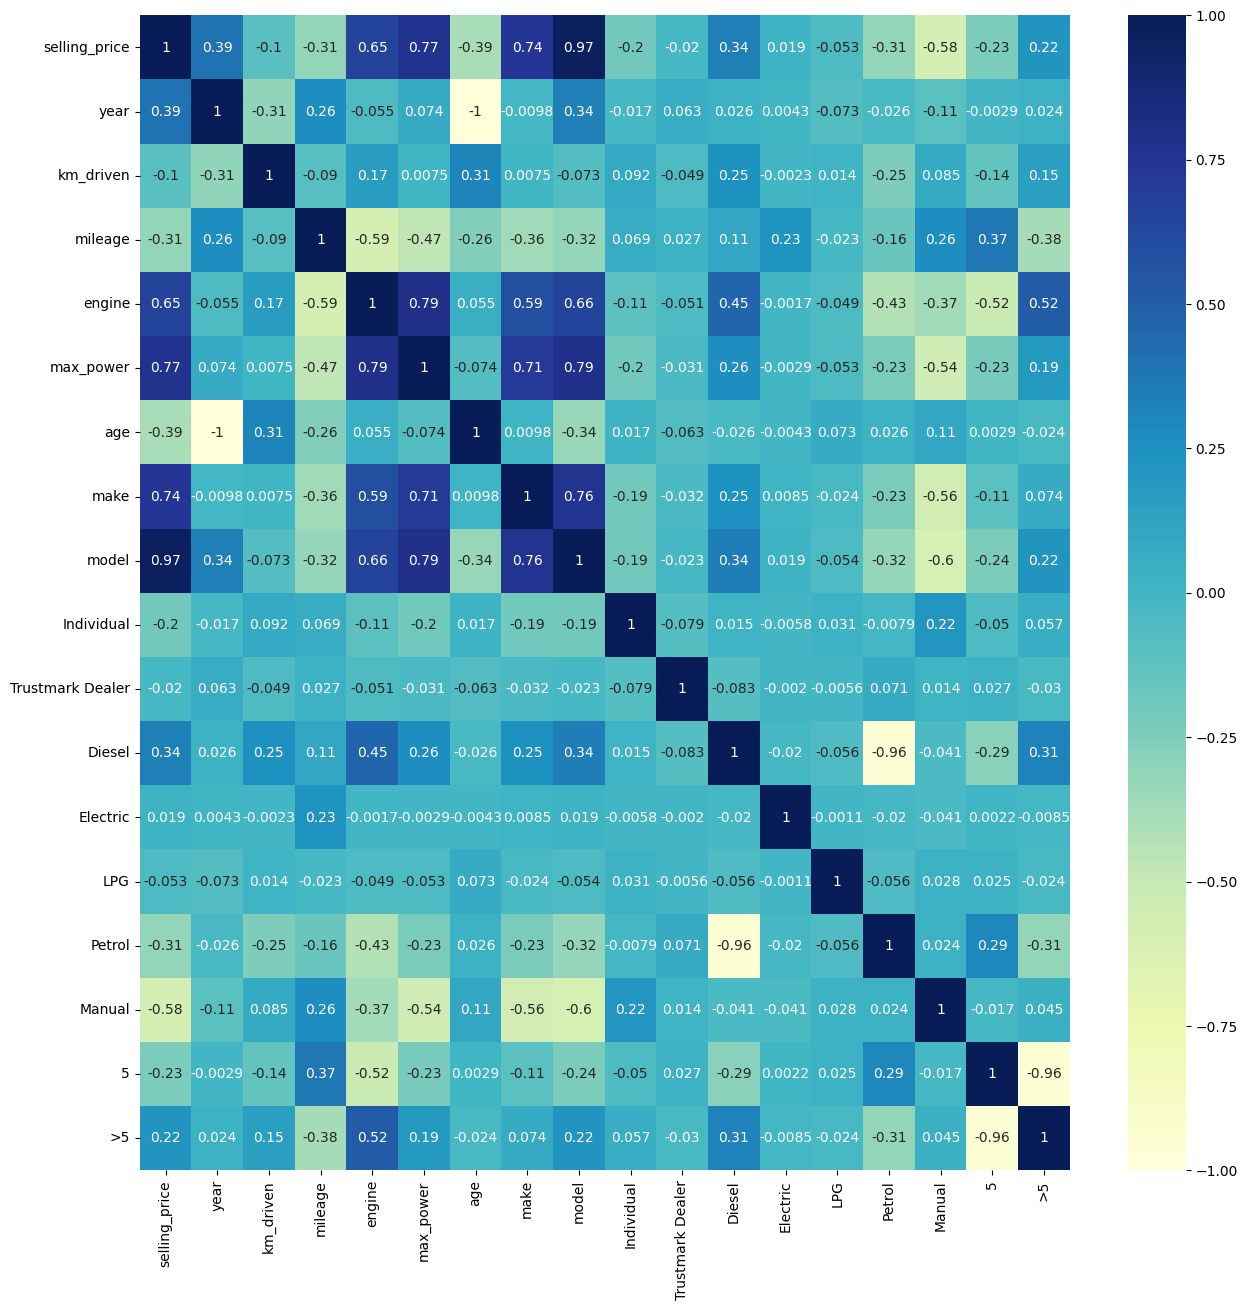

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)

In [ ]:
y = df["selling_price"]
X = df.drop("selling_price", axis=1)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MSE: ", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE", rmse)
r2 = r2_score(y_test, y_pred)
print("R2_SCORE", r2)


MSE:  0.05660307597213689
RMSE 0.05660307597213689
R2_SCORE 0.943748003943643
